In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
I_1 = 0.1 # [kg.m^2]
I_2 = 5 # [kg.m^2]
c = 25 # [N.m/rad]

In [ ]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            self.omega_n = self.calculate_natural_frequency()
        else:
            self.omega_n = None
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        self.A = np.array([
            [1, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, self.omega_n, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, self.omega_n],
            [1, 0, 0, 0, -1, 0, 0, 0],
            [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, -1, 0],
            [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
        ])
        self.b = np.array([initial_angle[0], initial_velocity[0], initial_angle[1], initial_velocity[1], 0, 0, 0, 0])
        A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
        t = np.linspace(0, time_span, 1000)
        theta_1 = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
        theta_2 = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2

In [ ]:
# Define an instance of the model
S = TwoDOFTorsionalSystem(I_1=I_1, I_2=I_2, c=c)

np.float64(15.968719422671311)

In [129]:
# Define Initial Conditions
theta_0 = [1, -0.1] # Initial angular position
theta_dot_0 = [-2, 0.1] # Initial angular velocity
# Calculate solution
t, theta_1, theta_2 = S.simulate_time_response(initial_angle=theta_0, initial_velocity=theta_dot_0)

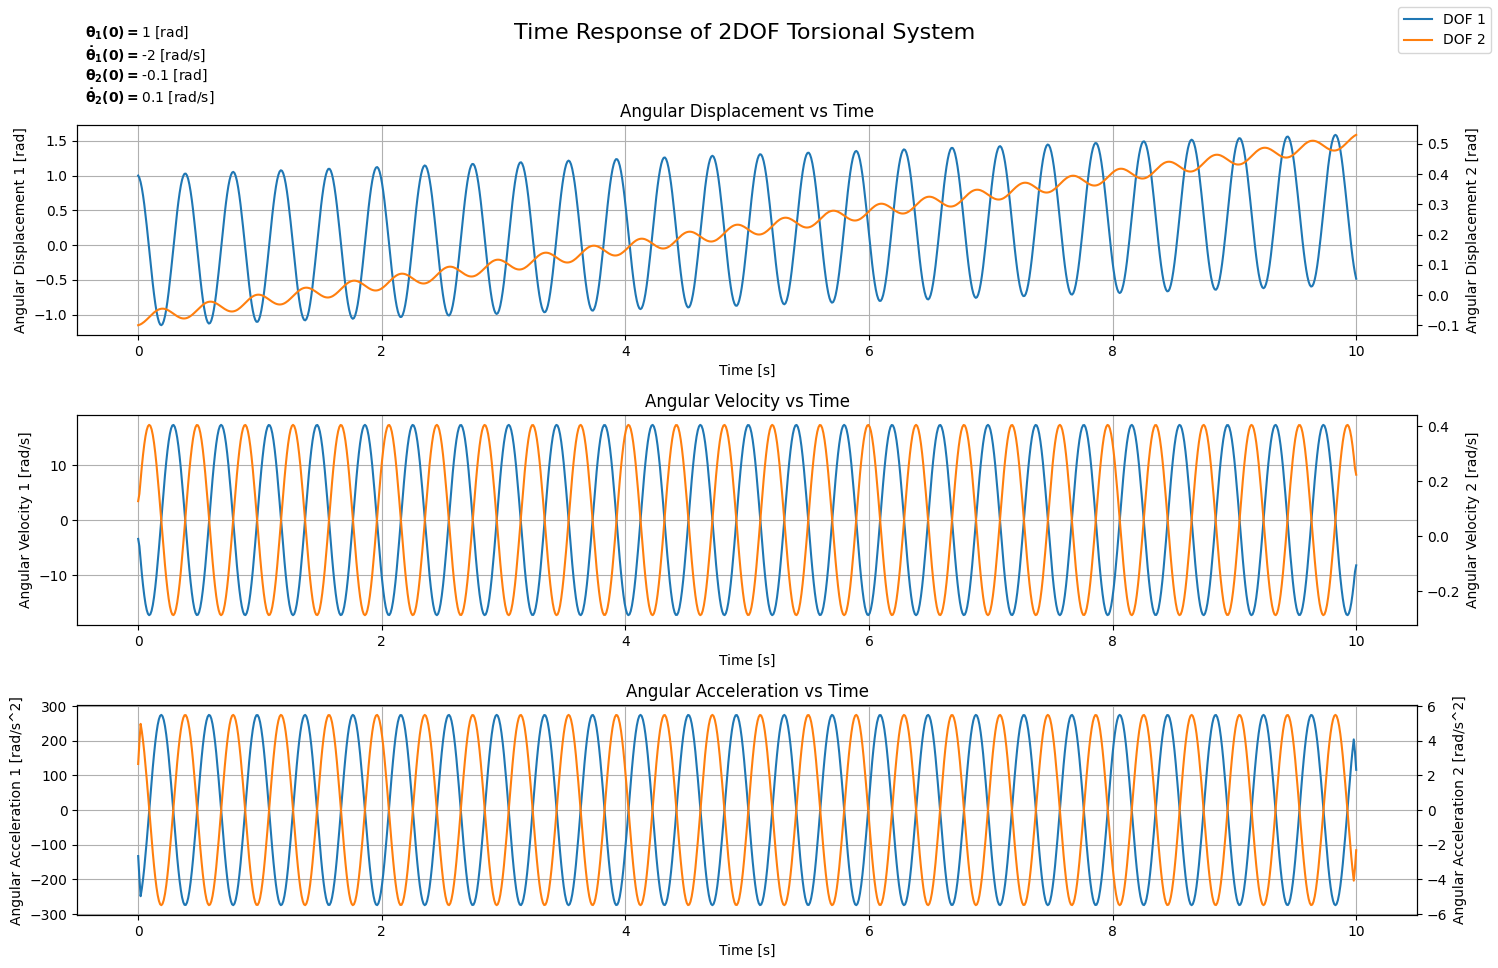

In [130]:
# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Time Response of 2DOF Torsional System', fontsize=16)
# Angular Displacement vs Time
ax2 = axes[0].twinx()
axes[0].plot(t, theta_1, label='DOF 1')
ax2.plot(t, theta_2, label='DOF 2', color='#ff7f0e')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement 1 [rad]')
ax2.set_ylabel('Angular Displacement 2 [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity_1 = np.gradient(theta_1, t, axis=0)
angular_velocity_2 = np.gradient(theta_2, t, axis=0)

ax2 = axes[1].twinx()
axes[1].plot(t, angular_velocity_1)
ax2.plot(t, angular_velocity_2, color='#ff7f0e')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity 1 [rad/s]')
ax2.set_ylabel('Angular Velocity 2 [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)

# Angular Acceleration vs Time
angular_acceleration_1 = np.gradient(angular_velocity_1, t, axis=0)
angular_acceleration_2 = np.gradient(angular_velocity_2, t, axis=0)

ax2 = axes[2].twinx()
axes[2].plot(t, angular_acceleration_1)
ax2.plot(t, angular_acceleration_2, color='#ff7f0e')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration 1 [rad/s^2]')
ax2.set_ylabel('Angular Acceleration 2 [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

fig.legend()
fig.text(0.06, 0.9, r"$\mathbf{\theta_1(0) = }$" + f"{theta_0[0]} [rad]" + "\n" + r"$\mathbf{\dot{\theta}_1(0) = }$" + f"{theta_dot_0[0]} [rad/s]" + "\n" + 
         r"$\mathbf{\theta_2(0) = }$" + f"{theta_0[1]} [rad]" + "\n" + r"$\mathbf{\dot{\theta}_2(0) = }$" + f"{theta_dot_0[1]} [rad/s]")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

## Adding Particular Solution - First Modal Coordinate

In [ ]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            # Natural frequency
            self.omega_n = self.calculate_natural_frequency()
            # Mode shapes
            self.phi_1_1 = 1
            self.phi_1_2 = 1
            self.phi_2_1 = 1
            self.phi_2_2 = -self.I_1 / self.I_2
            # Equivalent Inertia - Mode 1
            self.Ieq_1 = self.I_1 + self.I_2
            # Equivalent Inertia - Mode  2
            self.Ieq_2 = self.I_1 + self.I_1**2 / self.I_2
            # Equivalent Stiffness - Mode 2
            self.ceq = self.Ieq_2 * self.omega_n ** 2
        else:
            self.omega_n = None
            self.phi_1_1 = 0
            self.phi_1_2 = 0
            self.phi_2_1 = 0
            self.phi_2_2 = 0
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10,
                               load_type=["poly", "poly"], tau_ext=np.array[[0], [0]], dtype=np.float16):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        
        # Particular Solution
        # Time array
        t = np.linspace(0, time_span, 1000)
        # Natural frequency
        omega_n = self.omega_n
        if load_type == "poly":
            # TODO: Solve q1 analytically for polynomial
        else:
            raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")
        
        # General Solution
        self.A = np.array([
            [1, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, self.omega_n, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, self.omega_n],
            [1, 0, 0, 0, -1, 0, 0, 0],
            [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, -1, 0],
            [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
        ])
        self.b = np.array([initial_angle[0], initial_velocity[0], initial_angle[1], initial_velocity[1], 0, 0, 0, 0])
        A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
        t = np.linspace(0, time_span, 1000)
        theta_1_G = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
        theta_2_G = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2

In [ ]:
class TwoDOFTorsionalSystem:
    
    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1 > 0 and self.I_2 > 0 and self.c > 0:
            # Natural frequency
            self.omega_n = self.calculate_natural_frequency()
            # Mode shapes
            self.phi_1_1 = 1
            self.phi_1_2 = 1
            self.phi_2_1 = 1
            self.phi_2_2 = -self.I_1 / self.I_2
            # Equivalent Inertia - Mode 1
            self.Ieq_1 = self.I_1 + self.I_2
            # Equivalent Inertia - Mode  2
            self.Ieq_2 = self.I_1 + self.I_1**2 / self.I_2
            # Equivalent Stiffness - Mode 2
            self.ceq = self.Ieq_2 * self.omega_n ** 2
        else:
            self.omega_n = None
            self.phi_1_1 = 0
            self.phi_1_2 = 0
            self.phi_2_1 = 0
            self.phi_2_2 = 0
    
    # Method to calculate the natural frequency of the system: Out-of-phase vibration mode
    def calculate_natural_frequency(self):
        return np.sqrt(self.c * (self.I_1 + self.I_2) / (self.I_1 * self.I_2))
    
    # Method to simulate the time response of the system: Free Vibrations
    def simulate_time_response(self, initial_angle=np.array([0.0, 0.0]), initial_velocity=np.array([0.0, 0.0]), time_span=10,
                               load_type=["poly", "poly"], tau_ext=np.array[[0], [0]], dtype=np.float16):
        if self.omega_n is None:
            raise ValueError("Natural frequency is not defined. Please set inertias and stiffness.")
        
        # Particular Solution
        if load_type == "measurement":
            # TODO: Solve q1 numerically
            # Time array
            t = tau_ext['time']
            # Torque array on 1st DOF
            tau_1 = tau_ext['load'][0]
            # Torque array on 2nd DOF
            tau_2 = tau_ext['load'][1]
            # Modal force
            f_1 = self.phi_1_1 * tau_1 + self.phi_2_1 * tau_2
            # First integral
            d_q1 = np.trapz(f_1, t)
            # Second integral
            q1_t = np.trapz(d_q1, t) / self.Ieq_1
        else:
            # TODO: Check for poly or harmonic and solve q1 analytically
            # Time array
            t = np.linspace(0, time_span, 1000)
            # Natural frequency
            omega_n = self.omega_n
            # Initialize First Modal Solution to 0s
            q1P_t = np.zeros_like(t)
            # Group mode shapes corresponding to first mode
            phi_1 = np.array([self.phi_1_1, self.phi_2_1])
            for j, (lt, te) in enumerate(zip(load_type, tau_ext)):
                if lt == "poly":
                    # TODO: Solve q1 analytically for polynomial
                    q1P_i = np.zeros_like(te)
                    for i, coeff in enumerate(te):
                        ni = len(te)-1
                        q1P_i[i] = coeff / ((ni-i+2) * (ni-i+1)) # Coefficients of the first modal coordinate
                        q1P_t = q1P_t + phi_1[j] * q1P_i[i] * t ** (ni-i+2)
                elif lt == "harmonic":
                    # TODO: Solve q1 analytically for harmonic
                    if 'sin' in te:
                        A_s = te['sin']['amplitude']
                        omega_s = te['sin']['frequency'] * 2 * np.pi # Convert frequency from [Hz] to [rad/s]
                        if len(A_s) != len(omega_s):
                            raise Exception("Sin terms: amplitudes and frequencies must have the same length.")
                        q1P_i = np.zeros_like(A_s) # Sin terms of particular solution initialization
                        for i, (A_i, omega_i) in enumerate(zip(A_s, omega_s)):
                            q1P_i[i] = -A_i / omega_i**2
                            q1P_t = q1P_t + phi_1[j] * q1P_i[i] * np.sin(omega_i * t)
                    if 'cos' in te:
                        B_c = te['cos']['amplitude']
                        omega_c = te['sin']['frequency'] * 2 * np.pi # Convert frequency from [Hz] to [rad/s]
                        if len(B_c) != len(omega_c):
                            raise Exception("Cos terms: amplitudes and frequencies must have the same length.")
                        q1P_i = np.zeros_like(B_c) # Sin terms of particular solution initialization
                        for i, (B_i, omega_i) in enumerate(zip(B_c, omega_c)):
                            q1P_i[i] = -B_i / omega_i**2
                            q1P_t = q1P_t + phi_1[j] * q1P_i[i] * np.cos(omega_i * t)
                else:
                    raise ValueError("Unsupported load type. Please specify 'poly' for polynomial excitation, or 'harmonic' for harmonic excitation.")
            q1P_t = q1P_t / self.Ieq_1
        
            # General Solution
            self.A = np.array([
                [1, 1, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, self.omega_n, 0, 0, 0, 0],
                [0, 0, 0, 0, 1, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 1, self.omega_n],
                [1, 0, 0, 0, -1, 0, 0, 0],
                [0, self.I_1/self.I_2, 0, 0, 0, 1, 0, 0],
                [0, 0, 1, 0, 0, 0, -1, 0],
                [0, 0, 0, self.I_1/self.I_2, 0, 0, 0, 1]
            ])
            self.b = np.array([initial_angle[0], initial_velocity[0], initial_angle[1], initial_velocity[1], 0, 0, 0, 0])
            A_1_1, A_1_2, B_1_1, B_1_2, A_2_1, A_2_2, B_2_1, B_2_2 = np.linalg.solve(self.A, self.b)
            t = np.linspace(0, time_span, 1000)
            theta_1_G = A_1_1 + B_1_1 * t + A_1_2 * np.cos(self.omega_n * t) + B_1_2 * np.sin(self.omega_n * t)
            theta_2_G = A_2_1 + B_2_1 * t + A_2_2 * np.cos(self.omega_n * t) + B_2_2 * np.sin(self.omega_n * t)
        return t, theta_1, theta_2